# Custom CNN Inference (Same Preprocessing as Training)

This notebook loads your trained CustomCNN model, applies the same preprocessing used during training, and predicts a class for one image.

In [7]:
import json
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
# Paths and preprocessing constants (match training notebook)
MODEL_DIR = Path(r"C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models")

MODEL_PATH = None  # Optional: set a full .pth path here to force a specific model
CLASS_NAMES_PATH = MODEL_DIR / "class_names.json"

# Candidate model names in priority order when MODEL_PATH is None
MODEL_CANDIDATES = [
    "cnn_full_DATA_45epochs.pth",
    "custom_cnn_from_scratch_DA_fairness.pth",
    "custom_cnn_from_scratch_DA.pth",
    "custom_cnn_from_scratch_30epochs.pth",
    "custom_cnn_from_scratch.pth",
]

# Change this to any image you want to classify
IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou projecte\VAL\Banner aplicación\20260529103125_100034.png")
IMAGE_SIZE = (224, 224)
BORDER_CROP = 120
CONFIDENCE_THRESHOLD = 0.70

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.2f}")

Using device: cpu
Confidence threshold: 0.70


In [9]:
# Same architecture as training notebook
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112
            nn.Dropout(0.25),
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56
            nn.Dropout(0.25),
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28
            nn.Dropout(0.25),
        )
        
        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Dropout(0.25),
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [10]:
# Same preprocessing as training: safe crop + resize + normalization
def safe_mobile_border_crop(img):
    crop_margin = min(BORDER_CROP, max((img.height - 1) // 2, 0))
    return img.crop((0, crop_margin, img.width, img.height - crop_margin))

inference_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [11]:
# Load class names and model
if not CLASS_NAMES_PATH.exists():
    raise FileNotFoundError(f"class_names.json not found at: {CLASS_NAMES_PATH}")

if MODEL_PATH is None:
    resolved_model_path = None
    for name in MODEL_CANDIDATES:
        candidate = MODEL_DIR / name
        if candidate.exists():
            resolved_model_path = candidate
            break
    if resolved_model_path is None:
        raise FileNotFoundError(
            f"No model checkpoint found in {MODEL_DIR}. Checked: {MODEL_CANDIDATES}"
        )
else:
    resolved_model_path = Path(MODEL_PATH)
    if not resolved_model_path.exists():
        raise FileNotFoundError(f"Model file not found at: {resolved_model_path}")

with open(CLASS_NAMES_PATH, 'r', encoding='utf-8') as f:
    class_names = json.load(f)

model = CustomCNN(num_classes=len(class_names)).to(device)
state_dict = torch.load(resolved_model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded model: {resolved_model_path}")
print(f"Classes ({len(class_names)}): {class_names}")

Loaded model: C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\cnn_full_DATA_45epochs.pth
Classes (8): ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']


In [12]:
# Predict one image with threshold logic (same idea as validation)
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found at: {IMAGE_PATH}")

image = Image.open(IMAGE_PATH).convert('RGB')
input_tensor = inference_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu()

top_idx = int(torch.argmax(probs).item())
top_class = class_names[top_idx]
top_prob = float(probs[top_idx].item())

if top_prob < CONFIDENCE_THRESHOLD:
    predicted_label = "uncertain"
    decision = "REJECTED (below threshold)"
else:
    predicted_label = top_class
    decision = "ACCEPTED"

print(f"Image: {IMAGE_PATH}")
print(f"Predicted class: {predicted_label}")
print(f"Top class: {top_class}")
print(f"Confidence: {top_prob:.4f}")
print(f"Decision: {decision}")
print(f"Threshold: {CONFIDENCE_THRESHOLD:.2f}")

print("\nAll class probabilities:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {float(probs[i]):.4f}")

Image: C:\Users\ibf\Desktop\TFM\Nou projecte\VAL\Banner aplicación\20260529103125_100034.png
Predicted class: Banner aplicación
Top class: Banner aplicación
Confidence: 0.9864
Decision: ACCEPTED
Threshold: 0.70

All class probabilities:
  Banner aplicación: 0.9864
  Cierre aplicación: 0.0018
  Error aplicativo: 0.0044
  Error funcional: 0.0014
  Error terminal: 0.0013
  Indeterminado: 0.0022
  Revisión circuito: 0.0015
  Timeout: 0.0009


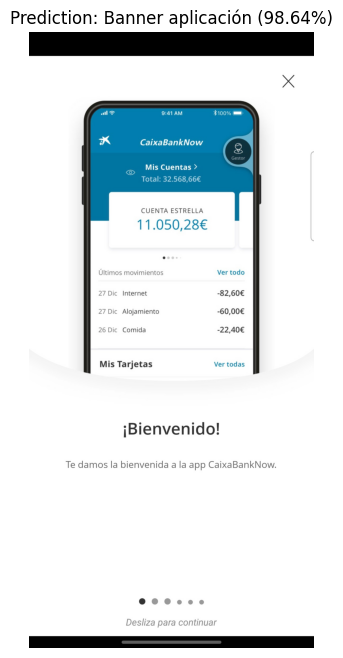

In [13]:
# Visualize input image
plt.figure(figsize=(5, 8))
plt.imshow(image)
plt.title(f"Prediction: {predicted_label} ({top_prob:.2%})")
plt.axis('off')
plt.show()